# Predicting heart disease using machine learning
This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model or algorithm capable of predicting whether or not someone has heart disease based on their medical attributes.

We're going to take the following approach:
1. Problem Statement
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation


## 1. Problem Definition

In a statement,
> Given clinical parameters about a patient,can we predict whether or not they have heart disease?

## 2. Data
The original data came from cleveland data from the UCI Machine learning Repository.
https://archive.ics.uci.edu/dataset/45/heart+disease

There is also a version of it available on Kaggle. https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data

## 3. Evaluation

> If we can 95% accuracy of predicting whether or not a patient has heart disease during the proof of concept, we'll pursue the project.

## 4. Features

This is where you'll get information about each of the features in your data.

**Create a data dictionary**

1. id (Unique id for each patient)
2. age (Age of the patient in years)
3. origin (place of study)
4. sex (1 = Male; 0 = Female)
5. cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
6. trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
7. chol (serum cholesterol in mg/dl)
8. fbs (if fasting blood sugar > 120 mg/dl)
9. restecg (resting electrocardiographic results)
10. Values: [normal, stt abnormality, lv hypertrophy]
11. thalach: maximum heart rate achieved
12. exang: exercise-induced angina (True = 1 ; False = 0)
13. oldpeak: ST depression induced by exercise relative to rest
14. slope: the slope of the peak exercise ST segment
15. ca: number of major vessels (0-3) colored by fluoroscopy
16. thal: [normal = 3; fixed = 6 defect; reversible defect =7]
17. target - have disease or not ( 1=yes or 0=no) (= the predicted attribute)


# Preparing the tools
We're going to use pandas, Matplotlib & Numpy for data analysis and manipulation(tweaking) 

In [63]:
# Importing all the tools we need 

# Regular EDA(exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# we want our plots to appear inside the notebook
%matplotlib inline  

# Models from scikit-learn
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

## Load data

In [64]:
df = pd.read_csv("heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [65]:
df.shape  ## (rows, columns)

(303, 14)

## Data Exploration (exploratory data analysis or EDA)

The goal here is to find out more about the data and become the subject matter export on the dataset you're working  with.

1. What question(s) are we trying to solve?
2. What kind of data do we have and how do we treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should we care about them?
5. How can you add, change or remove features to get more out of the data?


In [66]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [67]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [68]:
# Let's find how many of each class there is
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

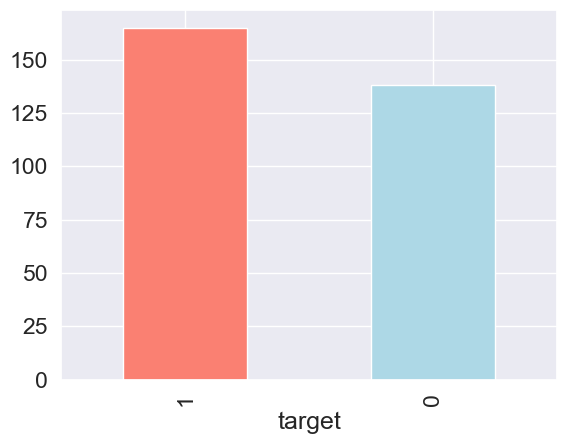

In [69]:
df["target"].value_counts().plot(kind="bar", color =["salmon",  "lightblue"]);

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [71]:
#Are there any missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [72]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency according to Sex

In [73]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [74]:
# Compare the target column with sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


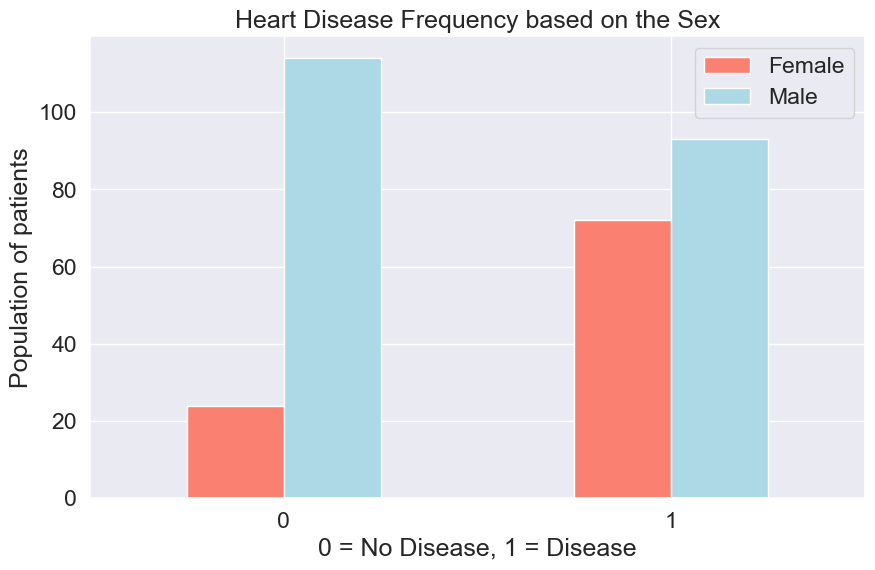

In [75]:
# Create a plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize =(10,6),
                                    color=["salmon", "lightblue"])

plt.title("Heart Disease Frequency based on the Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Population of patients")
plt.legend(["Female", "Male"]);
plt.xticks(rotation =0);

In [76]:
df["thalach"].value_counts()

thalach
162    11
160     9
163     9
152     8
173     8
       ..
202     1
184     1
121     1
192     1
90      1
Name: count, Length: 91, dtype: int64

## Age vs. Max Heart Rate For Heart Disease

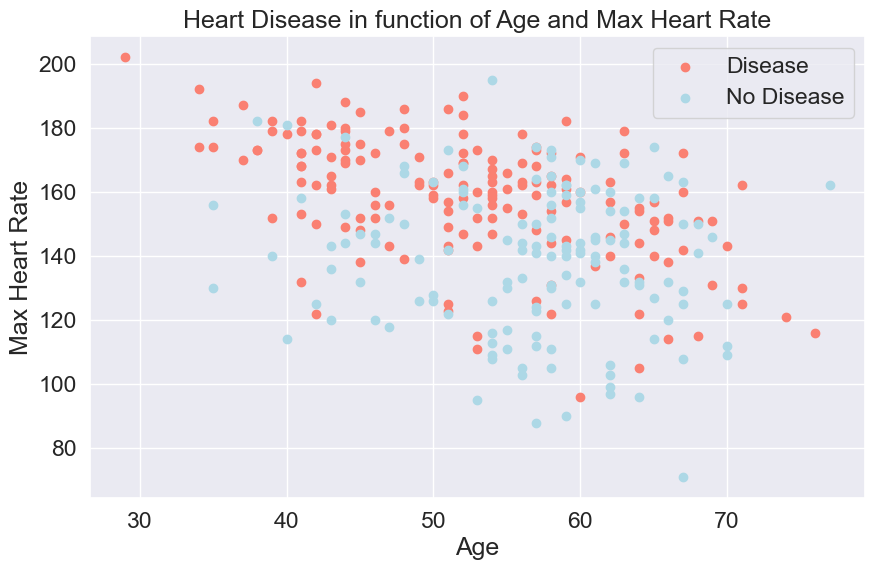

In [77]:
# Create another figure 
plt.figure(figsize=(10,6))

# Scatter with positive example
plt.scatter(df.age[df.target ==1],
            df.thalach[df.target==1],
            c = "salmon")

# Scatter with negative examples
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            c ="lightblue");

# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);

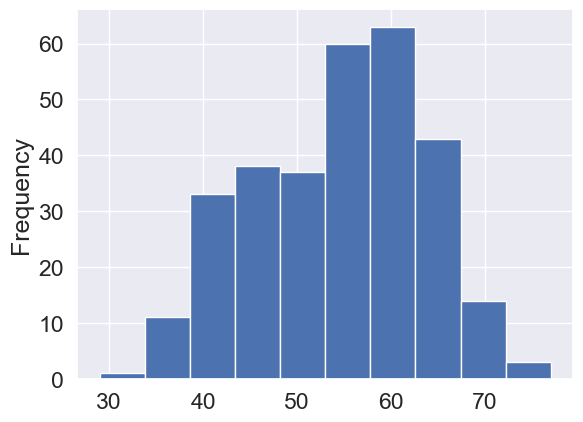

In [78]:
# Check the distribution of age column with histogram
df.age.plot.hist();

## Heart Disease Frequency per Chest Pain Type 
3. cp - chest pain type
 * 0:Typical angina: chest pain related decrease blood supply to the heart 
 * 1:Atypical angina: chest pain not related to heart 
 * 2:Non-anginal pain: typically esophageal spasms(non heart related)
 * 3:Asymptomatic: chest pain not showing signs of disease

In [79]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


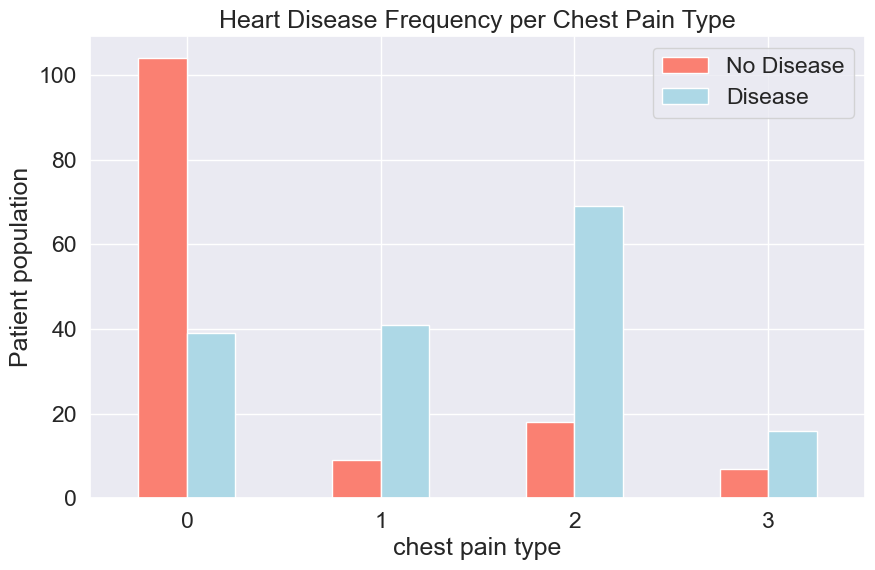

In [80]:
# Make the crosstab more visual
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   figsize=(10,6),
                                   color=["salmon", "lightblue"])

plt.title("Heart Disease Frequency per Chest Pain Type")
plt.xlabel("chest pain type")
plt.ylabel("Patient population")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0);

In [81]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [82]:
# Make a correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


(14.5, -0.5)

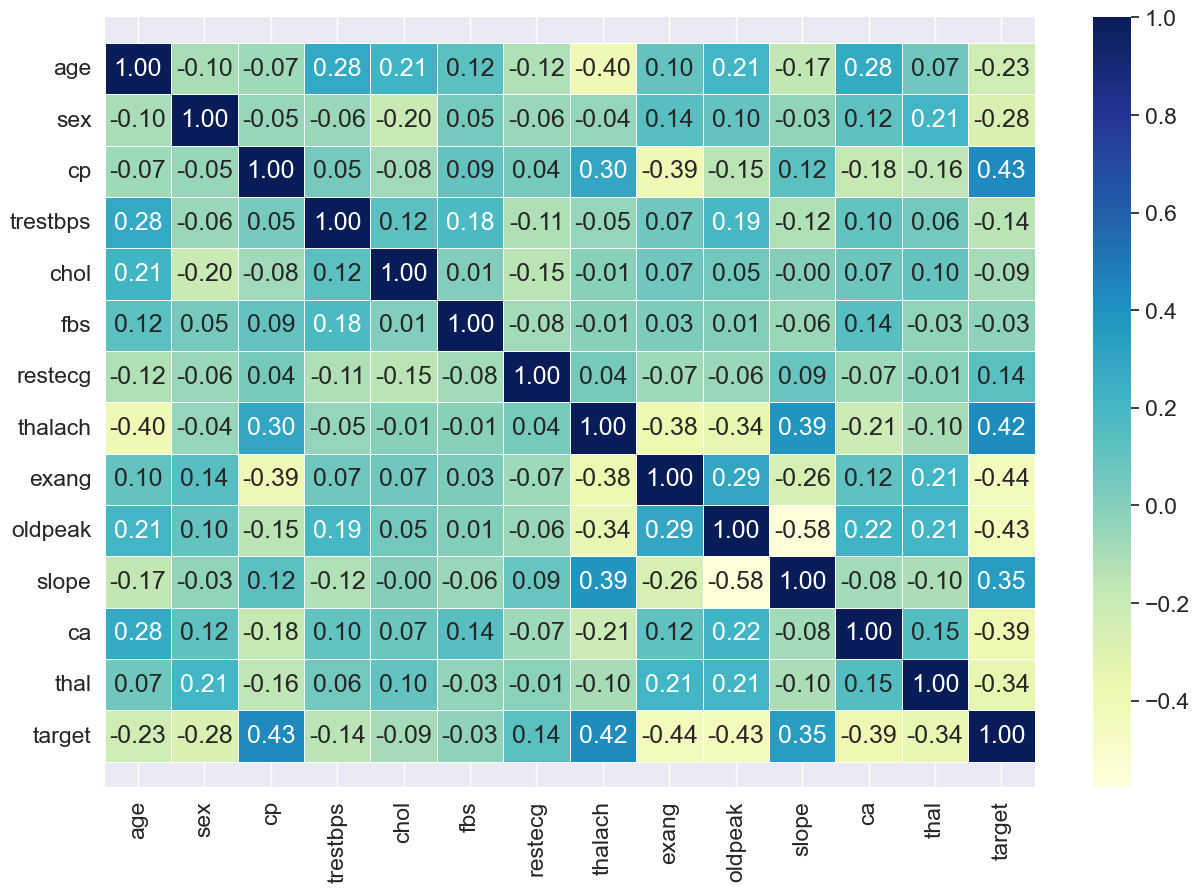

In [83]:
# Let's make our correlation matrix a little prettier
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt = ".2f",
                 cmap="YlGnBu");
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

## 5. Modelling

In [84]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [85]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [86]:
heart_disease =df

In [87]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [88]:
#splitting the data into feature variables, X &  labels,y
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

#Splitting the data into training and test dataset
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.15)

# Now we've got our data split into training and test sets, it's time to build  a machine learning model. 
#Training it to find patterns on the train dataset and we'll test it to use the patterns on the test set.
# Try out the 3 ML models:
# logistic Regression
#Random Forest Classifier
#KNeighbor Classifier

# Put models in a dictionary
models ={"Logistic Regression": LogisticRegression(),
         "KNN":KNeighborsClassifier(),
         "Random Forest":RandomForestClassifier()}

#Create a function to fit and score models 
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models :a dict of difference Scikit-learn machine learning models
    X_train : training data(no labels)
    X_test  : testing data(no labels)
    y_train : training labels
    y_test  : test labels
    """

    #set up a random seed 
    np.random.seed(42)

    #Make a dictionary to keep the model scores
    model_scores = {}

    #loop through models
    for name, model in models.items():
        #fit the model to the data
        model.fit(X_train, y_train)
        #Evaluate the model and append its scores to the model_scores
        model_scores[name] = model.score(X_test, y_test)

    return model_scores


In [89]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.7391304347826086,
 'KNN': 0.5869565217391305,
 'Random Forest': 0.6956521739130435}

# Model Comparison

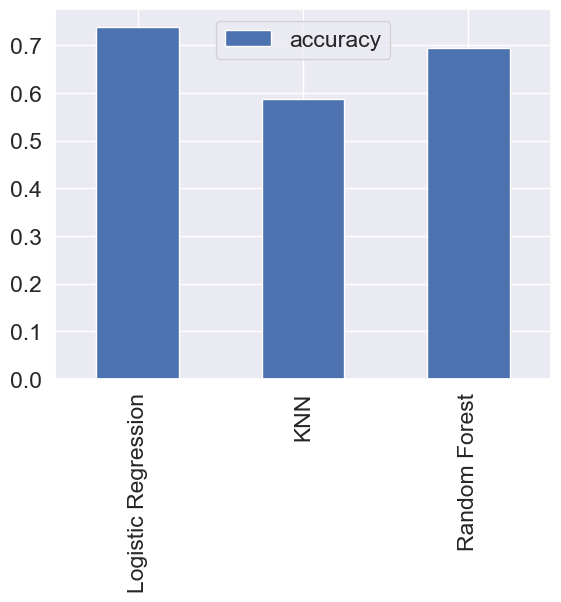

In [90]:
model_compare = pd.DataFrame(model_scores, index =["accuracy"])
model_compare.T.plot.bar();

In [91]:
model_compare

,Logistic Regression,KNN,Random Forest
accuracy,0.73913,0.586957,0.695652


# Now we've got a baseline model....and we know a model's first predictions aren't always what we should based our next steps off. What should we do?

Let's look at the following:
* Hyperparameter tuning
* Feature importance
* Confusion matrix
* Cross Validation
* Precision
* Recall
* F1 score
* Classification report
* ROC curve
* Area under the curve(AUC)

## Hyperparameter Tuning

In [92]:
# Let's tune KNN

train_scores = []
test_scores = []

# Create a list of different values for n_neigbours
neighbors = range(1, 21)

# Setup KNN instance
knn = KNeighborsClassifier()

#loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)

    #Fit the algorithm
    knn.fit(X_train, y_train)

    #Update the training scores list 
    train_scores.append(knn.score(X_train, y_train))

    #Update the test scores list
    test_scores.append(knn.score(X_test, y_test))

In [93]:
train_scores

[1.0,
 0.8249027237354085,
 0.7859922178988327,
 0.7782101167315175,
 0.77431906614786,
 0.7626459143968871,
 0.7665369649805448,
 0.7198443579766537,
 0.754863813229572,
 0.7354085603112841,
 0.7315175097276264,
 0.7315175097276264,
 0.7120622568093385,
 0.7198443579766537,
 0.708171206225681,
 0.7120622568093385,
 0.6848249027237354,
 0.7120622568093385,
 0.7042801556420234,
 0.7159533073929961]

In [94]:
test_scores

[0.6304347826086957,
 0.5217391304347826,
 0.5434782608695652,
 0.5434782608695652,
 0.5869565217391305,
 0.6521739130434783,
 0.6521739130434783,
 0.6086956521739131,
 0.5652173913043478,
 0.5434782608695652,
 0.5434782608695652,
 0.5434782608695652,
 0.5217391304347826,
 0.5217391304347826,
 0.5652173913043478,
 0.5434782608695652,
 0.5869565217391305,
 0.5434782608695652,
 0.5869565217391305,
 0.5652173913043478]

Maximum KNN score on the test data: 65.22%


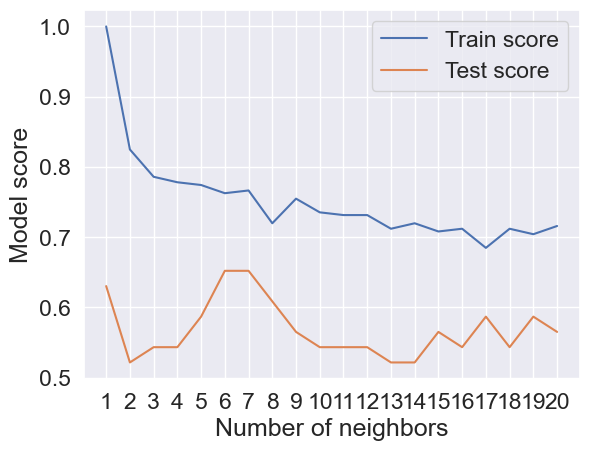

In [95]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1,21,1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

## Hyperparameter tuning with RandomizedSearchCV

We're going to tune:
* LogisticRegression()
* RandomForestClassifier()

  
...using RandomizedSearchCV

In [96]:
# Create a hyperparameter grid for LogisticRegression
log_reg_grid = {"C" : np.logspace(-4, 4, 20),
                "solver" : ["liblinear"]}

# Create a hyperparameter grid for RandomForestClassifier
rf_grid = {"n_estimators": np.arange(10, 2000, 50),
           "max_depth" : [None, 3, 5, 10],
           "min_samples_split" : np.arange(2, 20, 2),
           "min_samples_leaf" : np.arange(1, 20, 2)}

## Now we've got hyperparameter grids setup for each our models, let's tune them using RandomizedSearchCV...

In [97]:
# Tune logisticRegression

#Setup random seed
np.random.seed(42)

#Setup random hyperparameter search for logisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions = log_reg_grid,
                                cv = 5,
                                n_iter=20,
                                verbose = True)

# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [98]:
# Evaluate the randomized Search for LogisticRegression
rs_log_reg.score(X_test, y_test)

0.7391304347826086

# Now we've turned logisticRegression(), let's do the same for RandomForestClassifier()...

In [99]:
# Setup random seed
np.random.default_rng(seed=42)

# Setup the random Hyperparameter Search for RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           n_iter=20,
                           cv =5,
                           verbose = True)

#Fit the random Hyperparameter Search for RandomForestClassifier to the train data
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ..., 1910, 1960])}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [100]:
# Evaluate the randomized Search for RandomForestClassifier()
rs_rf.score(X_test, y_test)

0.7391304347826086

In [101]:
model_scores

{'Logistic Regression': 0.7391304347826086,
 'KNN': 0.5869565217391305,
 'Random Forest': 0.6956521739130435}

1. by hand
2. RandomizedSearchCV
3. GridSearchCV

## Hyperparameter Tuning with GridSearchCV

Since our RandomForestClassifier model provides the best scores so far, we'll try and improve them again using GridSearchCV... 

In [102]:
# Create a hyperparameter grid for RandomForestClassifier
#rf_grid = {"n_estimators": np.arange(10, 50, 10),
#            "max_depth" : [None, 3, 5, 10],
#            "min_samples_split" : np.arange(2, 20, 2),
#           "min_samples_leaf" : np.arange(1, 20, 2)}

# Setup grid Hyperparameter Search for RandomForestClassifier
#gs_rf = GridSearchCV(RandomForestClassifier(),
#                     param_grid = rf_grid,
#                    cv = 5,
#                     verbose = True)

# Fit the grid Search RandomForestClassifier
#gs_rf.fit(X_train, y_train)
                 

In [103]:
# Evaluate the grid Search RandomForestClassifier
#gs_rf.score(X_test, y_test)

## Since the logistic Regression provides the best results, we're gonna improve it using GridSearchCV

In [104]:
# Create a hyperparameter grid for LogisticRegression
log_reg_grid = {"C" : np.logspace(-4, 4, 20),
                "solver" : ["liblinear"]}

# Setup a grid hyperparameter for search LogisticRegression
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid = log_reg_grid,
                          cv =5,
                          verbose =True)

#Fit the grid hyperparameter for Search logisticRegression
gs_log_reg.fit(X_train, y_train)
                          
                      
                          

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [105]:
gs_log_reg.score(X_test, y_test)

0.7391304347826086

In [106]:
model_scores

{'Logistic Regression': 0.7391304347826086,
 'KNN': 0.5869565217391305,
 'Random Forest': 0.6956521739130435}

## Evaluating our turned machine learning classifier, beyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score
  ... and it would be great if cross-validation was used where possible.

  To make comparisons and evaluate our trained model, first we need to make predictions.

In [107]:
#Make a predictions with tuned model
y_preds = gs_log_reg.predict(X_test)
y_preds

array([1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0])

In [108]:
np.array(y_test)

array([1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0])

In [109]:
np.array(y_preds == y_test)

array([ True,  True, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True, False, False, False,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True])

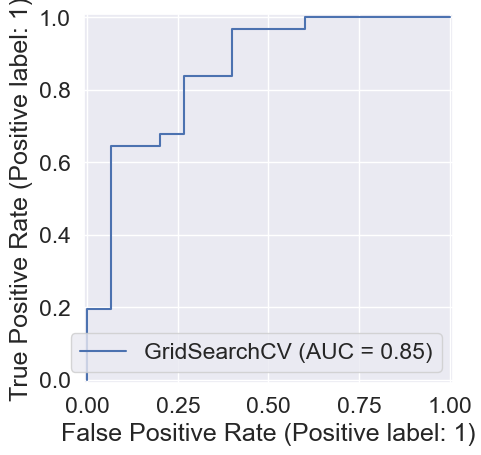

In [110]:
# Plot ROC curve and calculate AUC metric
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)
plt.show()

In [111]:
# Confusion matrix
print(confusion_matrix(y_test, y_preds))

[[11  4]
 [ 8 23]]


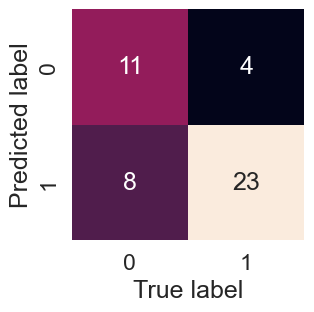

In [112]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar =False)

    plt.xlabel("True label")
    plt.ylabel("Predicted label")

plot_conf_mat(y_test, y_preds)

Now I've got a ROC curve, an AUC metric and a confusion matrix, let's get the classification report as well as cross-validated precision, recall and f1-score

In [113]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.58      0.73      0.65        15
           1       0.85      0.74      0.79        31

    accuracy                           0.74        46
   macro avg       0.72      0.74      0.72        46
weighted avg       0.76      0.74      0.75        46



### Calculate evaluation metrics using cross-validation

We're going calculate precision, recall, and F1 score of our model using cross-validation and to do so we'll be using `cross_val_score()`

In [114]:
# check the best hyperparameters
gs_log_reg.best_params_

{'C': np.float64(0.08858667904100823), 'solver': 'liblinear'}

In [115]:
# Create a new classifier with best parameters
clf = LogisticRegression(C = 0.23357214690901212,
                         solver = "liblinear")

In [116]:
#Cross-validated accuracy
cross_val_acc = cross_val_score(LogisticRegression(),
                                X,
                                y,
                                cv=5,
                                scoring = "accuracy")
cross_val_acc

C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/st

array([0.81967213, 0.86885246, 0.83606557, 0.83333333, 0.75      ])

In [117]:
np.mean(cross_val_acc)

np.float64(0.8215846994535518)

In [118]:
#Cross-validated precision
cross_val_precision = cross_val_score(LogisticRegression(),
                                      X,
                                      y,
                                      scoring = "precision",
                                      cv=5)
cross_val_precision

C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/st

array([0.78947368, 0.90322581, 0.84848485, 0.82857143, 0.725     ])

In [119]:
#Cross-validated F1-score
cross_val_f1 = cross_val_score(LogisticRegression(),
                                     X,
                                     y,
                                     cv=5,
                                     scoring = "f1")
cross_val_f1

C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/st

array([0.84507042, 0.875     , 0.84848485, 0.85294118, 0.79452055])

In [120]:
#Cross-validated recall
cross_val_recall = cross_val_score(LogisticRegression(),
                                   X,
                                   y,
                                   cv=5,
                                   scoring="recall")
cross_val_recall
                                

C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\DELL\Desktop\heart-disease-project\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/st

array([0.90909091, 0.84848485, 0.84848485, 0.87878788, 0.87878788])

In [121]:
np.mean(cross_val_acc)

np.mean(cross_val_precision)

np.mean(cross_val_f1)

np.mean(cross_val_recall)

np.float64(0.8727272727272727)

<Axes: title={'center': 'Cross-validated classification metrics'}>

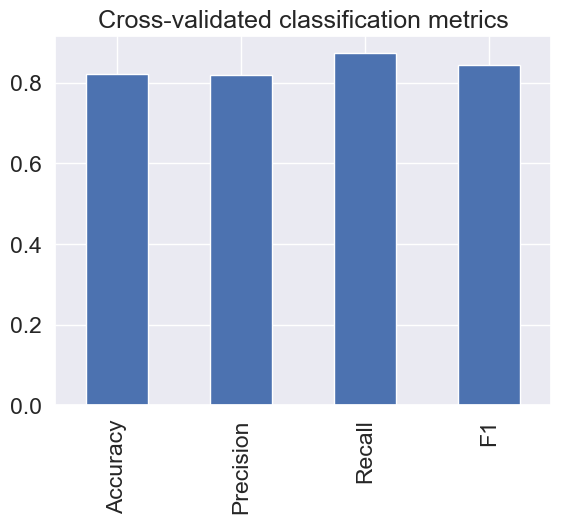

In [126]:
#Visualize cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy" :cross_val_acc.mean(),
                          "Precision" :cross_val_precision.mean(),
                          "Recall" : cross_val_recall.mean(),
                          "F1" : cross_val_f1.mean()},
                          index =[0])

cv_metrics = cv_metrics.astype(float)


cv_metrics.T.plot.bar(title ="Cross-validated classification metrics",
                      legend=False)
